## Multi-Variable Training
Goal: Enhance the baseline emulator by incorporating more inputs
- set 0: t_ref + spatial features (cos(lat), sin(lat), cos(lon), sin(lon))
- set 1: + land mask
- set 2: + z_surf
- set 3: + swdn_toa
- set 4: Remove z_surf

### Observations
- Land mask had minimal effect on performance
- Z_surf had a small negative effect. The validation losses during training were noisy, which may indicate that the model could benfit from retuning the hyperparameters or adding more epochs
- Adding insolation (swdn_toa) significantly improves performance, which is expected as it adds information about daily cycle and seasonal variations

In [1]:
from utils.utils import VarSet, DataSet
from architectures.cnn_baseline import CNN2D, set_seed, Results
import copy

nepochs = 50
Learning_Rate = 0.00016536937182824412
Layers = [64, 128, 128]
Batch_Size = 32
Optimizer = "AdamW"
Weight_Decay = 0.00012030178871154674

set_seed()

t_ref = VarSet(
    var_name="t_ref",
    file_name="PP_DATA/t_ref.192101-201012.nc",
    is_output=True
)

spatial_features = VarSet(
    var_name="spatial_features",
    file_name="PP_DATA/spatial_features.nc",
    is_static=True
)

land_mask = VarSet(
    var_name="land_mask",
    file_name="PP_DATA/land_mask.nc",
    is_static=True
)

zsurf = VarSet(
    var_name="zsurf",
    file_name="PP_DATA/zsurf_normalized.nc",
    is_static=True
)

swdn_toa = VarSet(
    var_name="swdn_toa",
    file_name="PP_DATA/swdn_toa.192101-201012.nc",
)


lon, lat = t_ref.get_grid()
time_test = t_ref.get_time('time_test')
Model_results = Results(lon, lat)


EncoderDecoder.set0 - Sequential(
  (0): Conv2d(7, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU()
  (6): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (8): ReLU(inplace=True)
  (9): ConvTranspose2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (11): ReLU(inplace=True)
  (12): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (13): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (14): ReLU(inplace=True)
  (15)

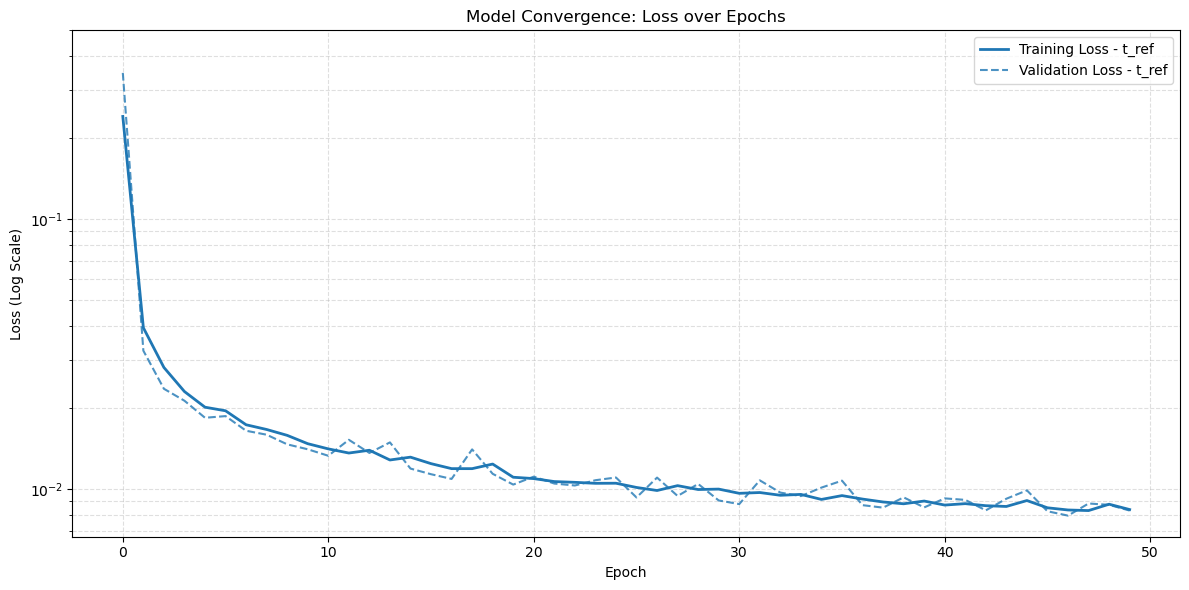

EncoderDecoder.set0 - Doing inference for 117 time steps
EncoderDecoder.set0-output - Size of the area weight:: (90, 90)
EncoderDecoder.set0-output - Calculating RMSE for target: t_ref
EncoderDecoder.set0-output - Global RMSE: t_ref :: 5.826901775926808


In [2]:
set_seed()
set0 = [copy.deepcopy(v) for v in [t_ref, spatial_features]]
data = DataSet(set_name=f"set0", variables=set0)
model = CNN2D(
        data,
        num_epochs=nepochs,
        batch_size=Batch_Size,
        lr=Learning_Rate,
        filters=Layers,
        weight_decay=Weight_Decay,
        optimizer=Optimizer,
        case=4,
        label=f"EncoderDecoder.set0",
        debug=True
    )
model.train()
model.plot_loss_over_epochs()
Model_results.add_model_output(model, run_type="forecast_rollout")

EncoderDecoder.set1 - Sequential(
  (0): Conv2d(8, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU()
  (6): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (8): ReLU(inplace=True)
  (9): ConvTranspose2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (11): ReLU(inplace=True)
  (12): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (13): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (14): ReLU(inplace=True)
  (15)

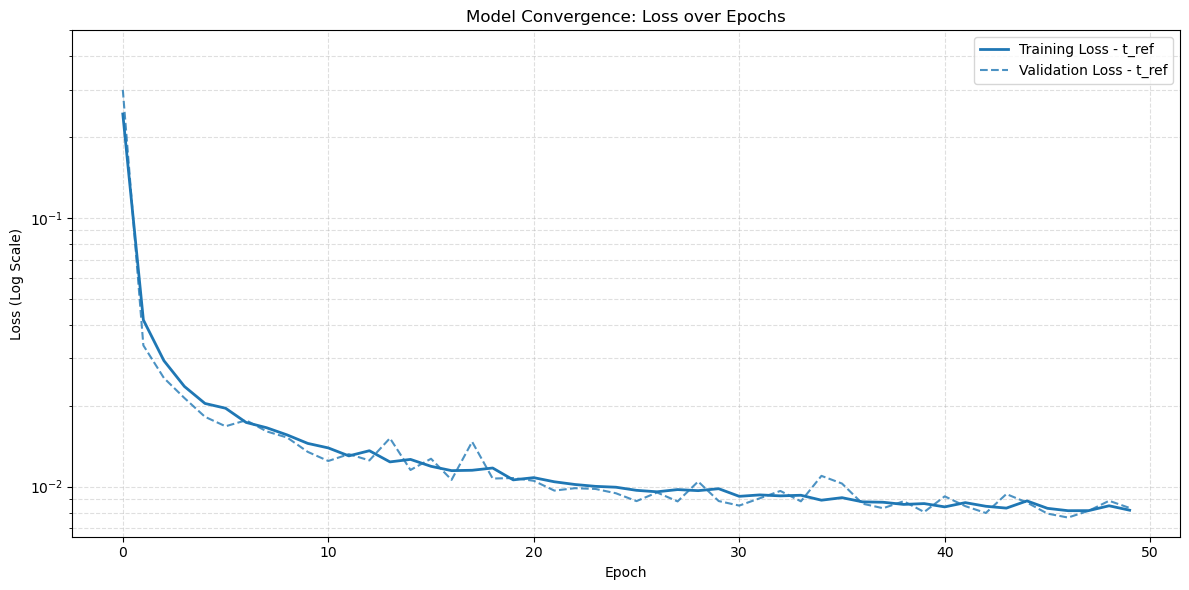

EncoderDecoder.set1 - Doing inference for 117 time steps
EncoderDecoder.set1-output - Size of the area weight:: (90, 90)
EncoderDecoder.set1-output - Calculating RMSE for target: t_ref
EncoderDecoder.set1-output - Global RMSE: t_ref :: 5.521098236078985


In [3]:
set_seed()
set1 = [copy.deepcopy(v) for v in [t_ref, spatial_features, land_mask]]
data = DataSet(set_name=f"set1", variables=set1)
model = CNN2D(
        data,
        num_epochs=nepochs,
        batch_size=Batch_Size,
        lr=Learning_Rate,
        filters=Layers,
        weight_decay=Weight_Decay,
        optimizer=Optimizer,
        case=4,
        label=f"EncoderDecoder.set1",
        debug=True
    )
model.train()
model.plot_loss_over_epochs()
Model_results.add_model_output(model, run_type="forecast_rollout")

EncoderDecoder.set2b - Sequential(
  (0): Conv2d(9, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU()
  (6): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (8): ReLU(inplace=True)
  (9): ConvTranspose2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (11): ReLU(inplace=True)
  (12): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (13): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (14): ReLU(inplace=True)
  (15

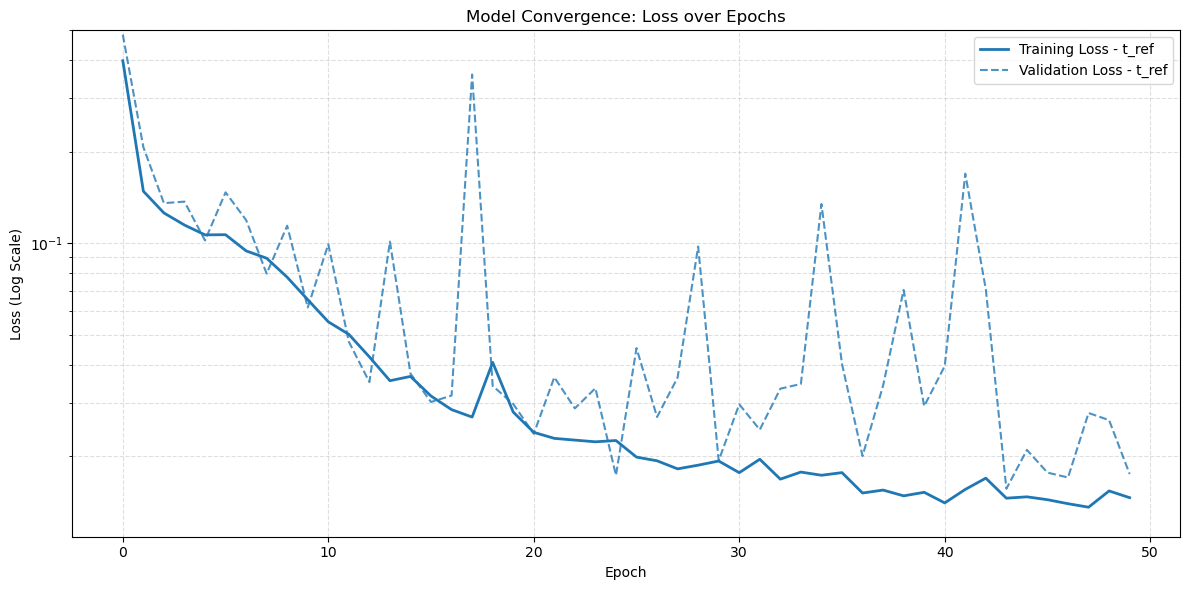

EncoderDecoder.set2b - Doing inference for 117 time steps
EncoderDecoder.set2b-output - Size of the area weight:: (90, 90)
EncoderDecoder.set2b-output - Calculating RMSE for target: t_ref
EncoderDecoder.set2b-output - Global RMSE: t_ref :: 6.043919246364955


In [4]:
set_seed()
set2 = [copy.deepcopy(v) for v in [t_ref, spatial_features, land_mask, zsurf]]
data = DataSet(set_name=f"set2", variables=set2)
model = CNN2D(
        data,
        num_epochs=nepochs,
        batch_size=Batch_Size,
        lr=Learning_Rate,
        filters=Layers,
        weight_decay=Weight_Decay,
        optimizer=Optimizer,
        case=4,
        label=f"EncoderDecoder.set2b",
        debug=True
    )
model.train()
model.plot_loss_over_epochs()
Model_results.add_model_output(model, run_type="forecast_rollout")

EncoderDecoder.set3b - Sequential(
  (0): Conv2d(12, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU()
  (6): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (8): ReLU(inplace=True)
  (9): ConvTranspose2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (11): ReLU(inplace=True)
  (12): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (13): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (14): ReLU(inplace=True)
  (1

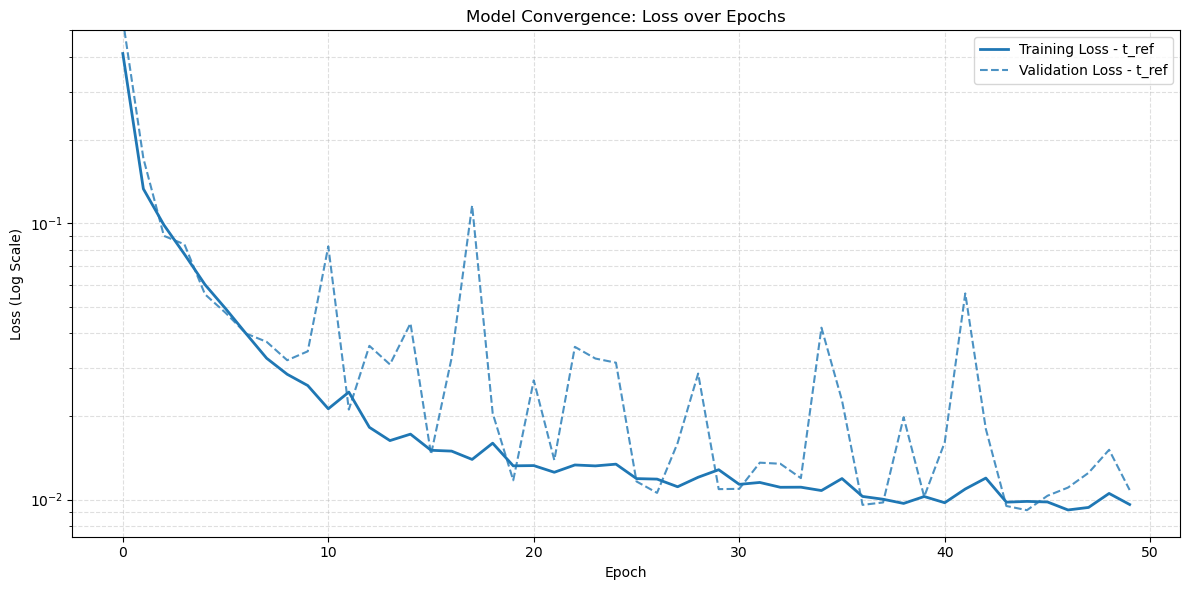

EncoderDecoder.set3b - Doing inference for 117 time steps
EncoderDecoder.set3b-output - Size of the area weight:: (90, 90)
EncoderDecoder.set3b-output - Calculating RMSE for target: t_ref
EncoderDecoder.set3b-output - Global RMSE: t_ref :: 2.509234977524933


In [5]:
set_seed()
set3 = [copy.deepcopy(v) for v in [t_ref, spatial_features, land_mask, zsurf, swdn_toa]]
data = DataSet(set_name=f"set3", variables=set3)
model = CNN2D(
        data,
        num_epochs=nepochs,
        batch_size=Batch_Size,
        lr=Learning_Rate,
        filters=Layers,
        weight_decay=Weight_Decay,
        optimizer=Optimizer,
        case=4,
        label=f"EncoderDecoder.set3b",
        debug=True
    )
model.train()
model.plot_loss_over_epochs()
Model_results.add_model_output(model, run_type="forecast_rollout")

EncoderDecoder.set4 - Sequential(
  (0): Conv2d(10, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU()
  (6): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (8): ReLU(inplace=True)
  (9): ConvTranspose2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (11): ReLU(inplace=True)
  (12): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (13): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (14): ReLU(inplace=True)
  (15

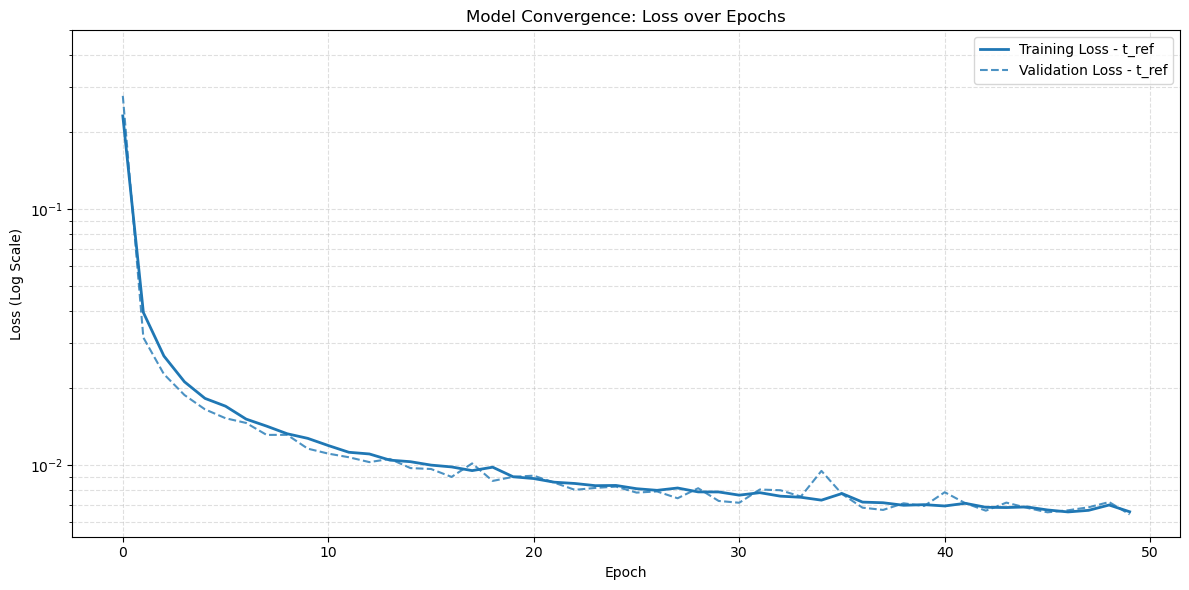

EncoderDecoder.set4 - Doing inference for 117 time steps
EncoderDecoder.set4-output - Size of the area weight:: (90, 90)
EncoderDecoder.set4-output - Calculating RMSE for target: t_ref
EncoderDecoder.set4-output - Global RMSE: t_ref :: 2.1853217313119626


In [6]:
set_seed()
set4 = [copy.deepcopy(v) for v in [t_ref, spatial_features, swdn_toa]]
data = DataSet(set_name=f"set4", variables=set4)
model = CNN2D(
        data,
        num_epochs=nepochs,
        batch_size=Batch_Size,
        lr=Learning_Rate,
        filters=Layers,
        weight_decay=Weight_Decay,
        optimizer=Optimizer,
        case=4,
        label=f"EncoderDecoder.set4",
        debug=True
    )
model.train()
model.plot_loss_over_epochs()
Model_results.add_model_output(model, run_type="forecast_rollout")

/net/unr/SPEAR_EMULATOR/architectures/cnn_baseline.py:666: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  time_converted = time_test.to_index().to_datetimeindex()
/net/unr/SPEAR_EMULATOR/architectures/cnn_baseline.py:666: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'julian', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  time_converted = time_test.to_index().to_datetimeindex()


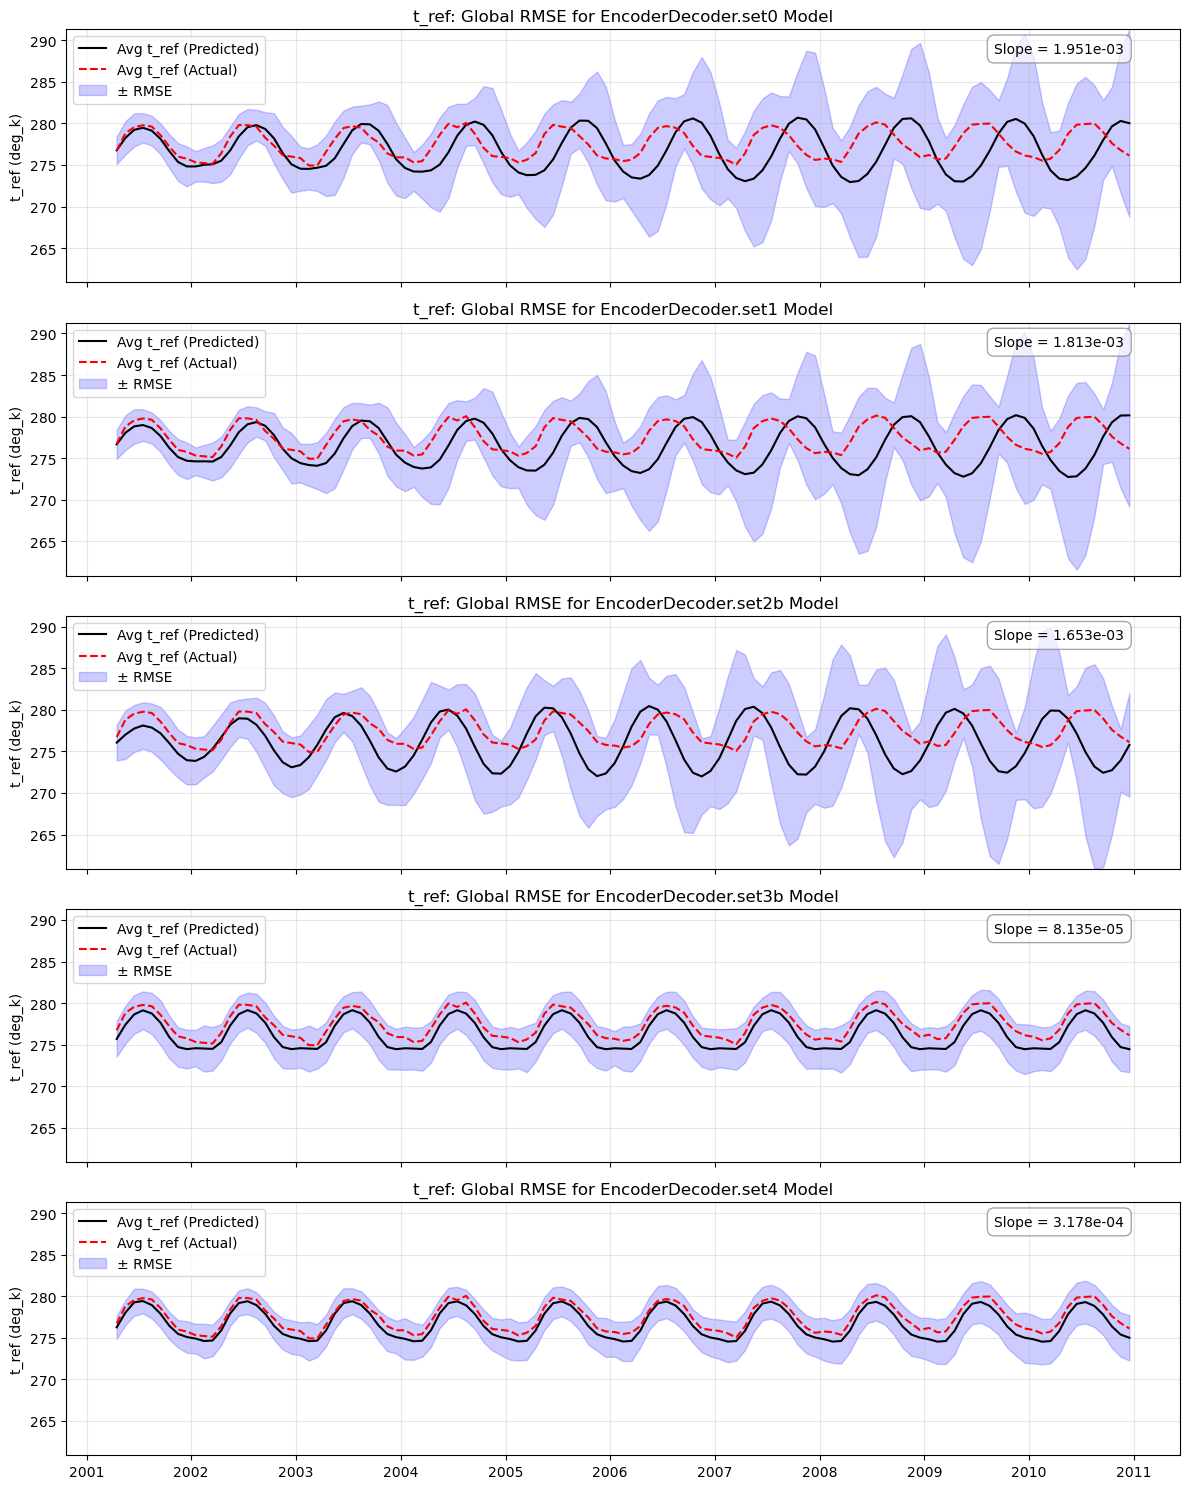

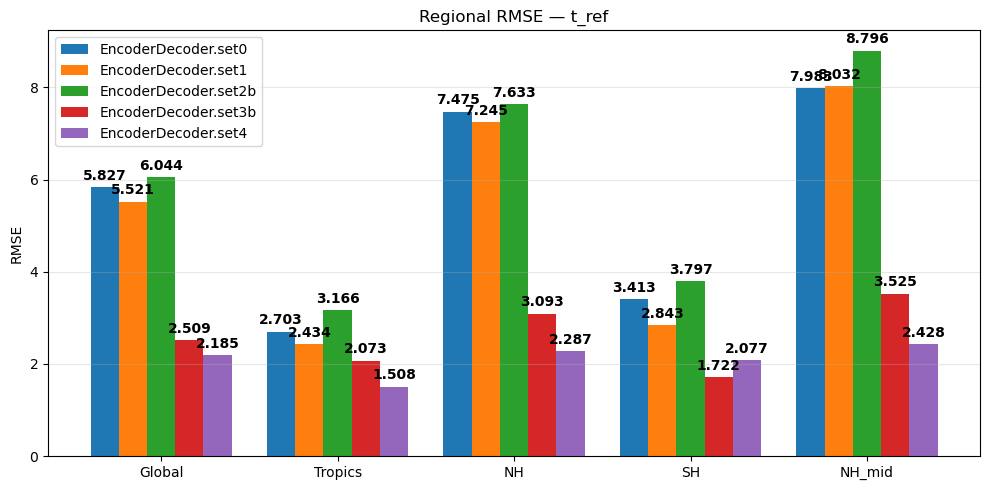

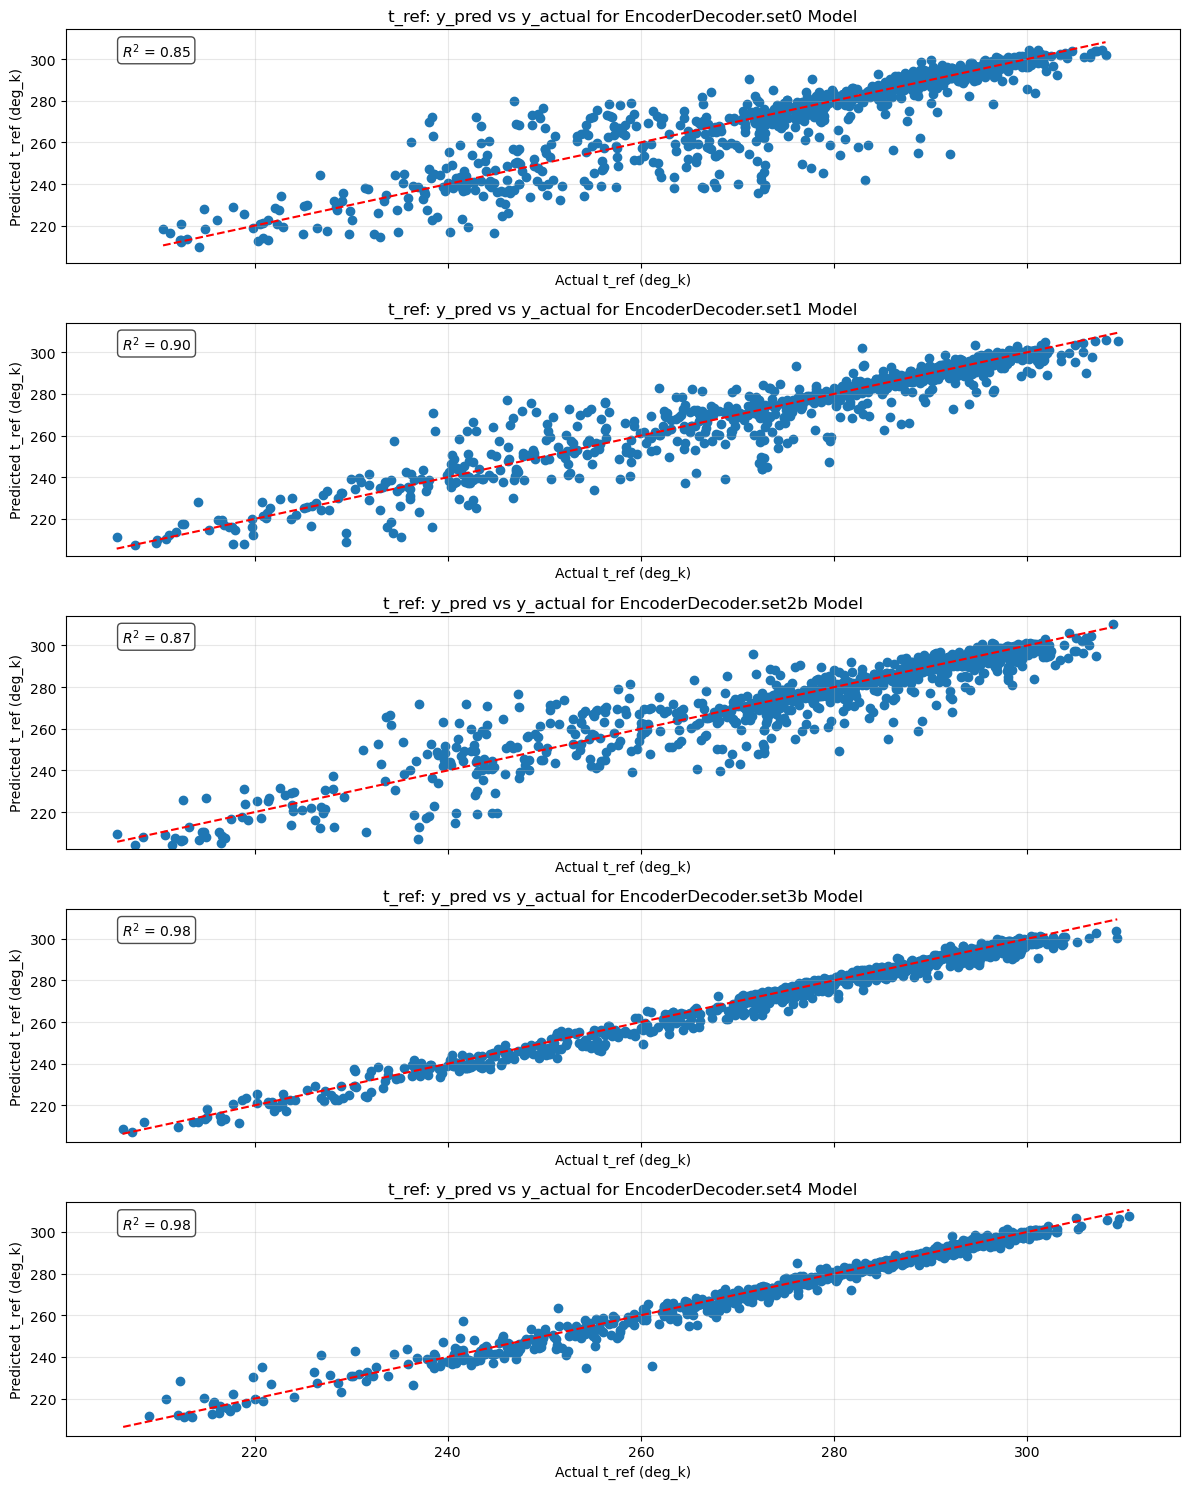

In [7]:
Model_results.plot_temporal_RMSE('t_ref', time_test)
Model_results.plot_regional_RMSE('t_ref')
Model_results.plot_scatter_y_pred_vs_y_actual("t_ref")